In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from pprint import pprint

from desdeo.problem.testproblems import (summer_cabin_battery_problem, 
                                         summer_cabin_battery_problem_split,
                                         summer_cabin_battery_problem_split_scenario)
from desdeo.tools import add_epsilon_constraints
from desdeo.tools.gurobipy_solver_interfaces import GurobipySolver

In [2]:
prob = summer_cabin_battery_problem_split()
print("Objectives:", [o.symbol for o in prob.objectives])
print("Variables: ", [v.symbol for v in prob.variables])

Objectives: ['f_1', 'f_2']
Variables:  ['y', 'E', 'n', 'c_s1', 'd_s1', 'soc_s1', 'buy_s1', 'sell_s1', 'c_s2', 'd_s2', 'soc_s2', 'buy_s2', 'sell_s2', 'c_s3', 'd_s3', 'soc_s3', 'buy_s3', 'sell_s3']


/home/juho/code/DESDEO/desdeo/problem/testproblems/summer_cabin_electricity.py:28: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.date_range("2025-06-01", "2025-08-31 23:00", freq="H")


## Find the ideal point

Minimize `f_1` (electricity cost) with `f_2` (investment cost) effectively unconstrained to find the best achievable electricity cost and the corresponding investment.

In [3]:
problem_unconstrained, scal_sym, _ = add_epsilon_constraints(
    problem=prob,
    symbol="eps_scal",
    constraint_symbols={"f_2": "eps_f2"},
    objective_symbol="f_1",
    epsilons={"f_2": 1e9},
)

result_ideal = GurobipySolver(problem_unconstrained).solve(scal_sym)

f1_ideal = result_ideal.optimal_objectives["f_1"]
f2_at_f1_ideal = result_ideal.optimal_objectives["f_2"]

print(f"f1 ideal  = {f1_ideal:.2f} EUR")
print(f"f2 at f1* = {f2_at_f1_ideal:.2f} EUR  (battery + solar investment to achieve it)")

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2555758
Academic license 2555758 - for non-commercial use only - registered to ju___@jyu.fi
f1 ideal  = -170.53 EUR
f2 at f1* = 25020.00 EUR  (battery + solar investment to achieve it)


## Pareto front sweep

Sweep `epsilon_f2` from 0 (no investment allowed) up to the value at the f1 ideal.
For each epsilon, minimize `f_1` subject to `f_2 ≤ epsilon`.

In [4]:
N_POINTS = 25
epsilons_f2 = np.linspace(0, f2_at_f1_ideal, N_POINTS)

pareto_f1 = []
pareto_f2 = []

for eps in epsilons_f2:
    problem_eps, scal_sym, _ = add_epsilon_constraints(
        problem=prob,
        symbol="eps_scal",
        constraint_symbols={"f_2": "eps_f2"},
        objective_symbol="f_1",
        epsilons={"f_2": float(eps)},
    )

    result = GurobipySolver(problem_eps).solve(scal_sym)

    if result.success:
        f1 = result.optimal_objectives["f_1"]
        f2 = result.optimal_objectives["f_2"]
        pareto_f1.append(f1)
        pareto_f2.append(f2)
        print(f"eps={eps:7.0f}  →  f1={f1:8.2f} EUR,  f2={f2:7.2f} EUR")
        print(f"  (battery capacity: {(result.optimal_variables['E']*result.optimal_variables['y']):.1f} kWh, "
              f"solar panels: {result.optimal_variables['n']:.1f} units)")
    else:
        print(f"eps={eps:7.0f}  →  FAILED: {result.message}")

eps=      0  →  f1=  282.75 EUR,  f2=   0.00 EUR
  (battery capacity: 0.0 kWh, solar panels: 0.0 units)
eps=   1042  →  f1=  243.63 EUR,  f2=1000.00 EUR
  (battery capacity: 0.0 kWh, solar panels: 5.0 units)
eps=   2085  →  f1=  205.91 EUR,  f2=2000.00 EUR
  (battery capacity: 0.0 kWh, solar panels: 10.0 units)
eps=   3128  →  f1=  171.61 EUR,  f2=3000.00 EUR
  (battery capacity: 0.0 kWh, solar panels: 15.0 units)
eps=   4170  →  f1=  141.83 EUR,  f2=4000.00 EUR
  (battery capacity: 0.0 kWh, solar panels: 20.0 units)
eps=   5212  →  f1=  110.69 EUR,  f2=5200.00 EUR
  (battery capacity: 0.0 kWh, solar panels: 26.0 units)
eps=   6255  →  f1=   87.53 EUR,  f2=6200.00 EUR
  (battery capacity: 0.0 kWh, solar panels: 31.0 units)
eps=   7298  →  f1=   66.26 EUR,  f2=7200.00 EUR
  (battery capacity: -0.0 kWh, solar panels: 36.0 units)
eps=   8340  →  f1=   46.26 EUR,  f2=8200.00 EUR
  (battery capacity: -0.0 kWh, solar panels: 41.0 units)
eps=   9382  →  f1=   27.19 EUR,  f2=9200.00 EUR
  (bat

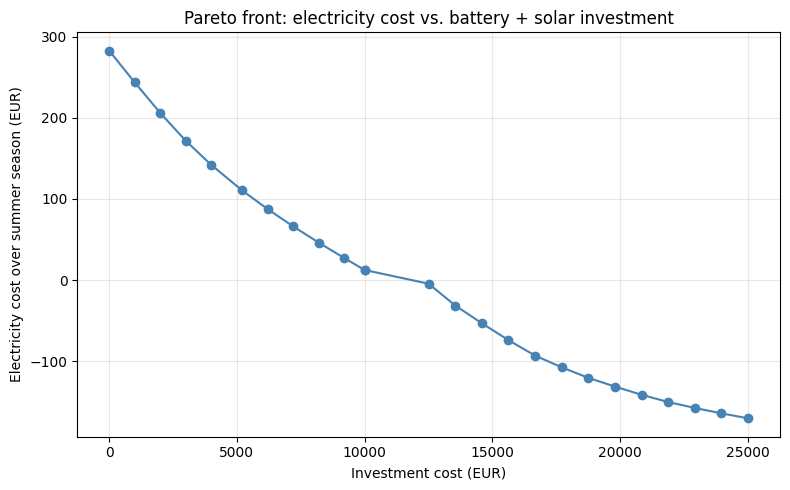

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pareto_f2, pareto_f1, marker="o", color="steelblue")
ax.set_xlabel("Investment cost (EUR)")
ax.set_ylabel("Electricity cost over summer season (EUR)")
ax.set_title("Pareto front: electricity cost vs. battery + solar investment")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()